# MNIST Digit Classification with CNN

This project uses TensorFlow/Keras to build and train a convolutional neural network (CNN) for handwritten digit classification on the MNIST dataset.

The workflow includes data preprocessing, one-hot encoding, CNN model development, training with early stopping, learning-curve analysis, test-set evaluation and a confusion matrix.


## 1. Data Loading and Preprocessing


In [169]:
import tensorflow as tf

(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [170]:
total_length = len(X_train_full) + len(X_test)
train_set_length = int((5 / 7) * total_length)

In [171]:
# split and normalize the training, validation and test sets
X_train, y_train = X_train_full[:train_set_length]/255., y_train_full[:train_set_length]
X_valid, y_valid = X_train_full[train_set_length:]/255., y_train_full[train_set_length:]
X_test = X_test/255.

In [172]:
# reshape the input data to 28,28,1
X_train = X_train.reshape((-1, 28, 28, 1))
X_valid = X_valid.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

## 2. One-Hot Encoding


The target labels are converted to one-hot encoded vectors using `to_categorical()`.


In [173]:
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, num_classes=10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=10)

## 3. CNN Architecture


In [174]:
tf.random.set_seed(42)  #ensures reproducibility

In [175]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(8, kernel_size=5, strides=2, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(16, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(units=32, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

In [176]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 8)         208       
                                                                 
 max_pooling2d (MaxPooling2  (None, 7, 7, 8)           0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 16)          1168      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 3, 3, 16)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 32)          4640      
                                                                 
 flatten_1 (Flatten)         (None, 288)              

## 4. Model Compilation


Because the target labels are one-hot encoded, the model uses categorical cross-entropy as the loss function.


In [177]:
model.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

## 5. Model Training with Early Stopping


In [178]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                  patience=5,
                                                  restore_best_weights=True)

history_early_stopping = model.fit(X_train, y_train_onehot, 
                                                  epochs=100,
                                                  validation_data=(X_valid, y_valid_onehot),
                                                  callbacks=[early_stopping])

Epoch 1/100
1563/1563 [==============================] - 13s 7ms/step - loss: 0.3766 - accuracy: 0.8771 - val_loss: 0.1240 - val_accuracy: 0.9606
Epoch 2/100
1563/1563 [==============================] - 11s 7ms/step - loss: 0.1285 - accuracy: 0.9583 - val_loss: 0.0816 - val_accuracy: 0.9764
Epoch 3/100
1563/1563 [==============================] - 11s 7ms/step - loss: 0.0983 - accuracy: 0.9680 - val_loss: 0.0727 - val_accuracy: 0.9795
Epoch 4/100
1563/1563 [==============================] - 11s 7ms/step - loss: 0.0808 - accuracy: 0.9743 - val_loss: 0.0692 - val_accuracy: 0.9788
Epoch 5/100
1563/1563 [==============================] - 11s 7ms/step - loss: 0.0736 - accuracy: 0.9763 - val_loss: 0.0691 - val_accuracy: 0.9782
Epoch 6/100
1563/1563 [==============================] - 11s 7ms/step - loss: 0.0640 - accuracy: 0.9800 - val_loss: 0.0689 - val_accuracy: 0.9796
Epoch 7/100
1563/1563 [==============================] - 13s 8ms/step - loss: 0.0598 - accuracy: 0.9808 - val_loss: 0.0629 -

## 6. Training History


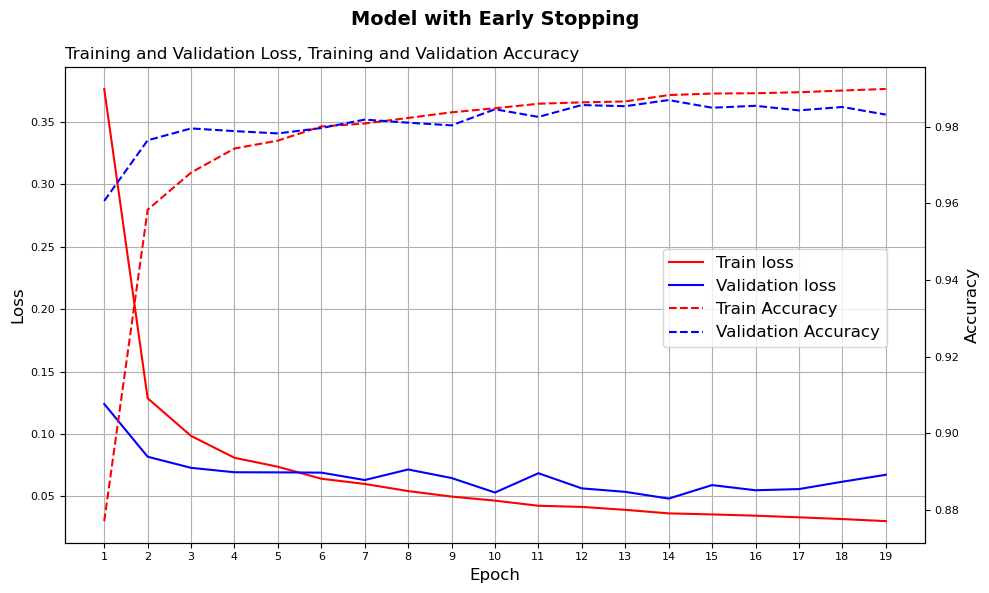

In [179]:
import matplotlib.pyplot as plt

x_values = range(1, len(history_early_stopping.history['loss']) + 1)
fig, ax = plt.subplots(figsize=(10, 6))

# Loss
ax.plot(x_values, history_early_stopping.history['loss'], "r-", label="Train loss")
ax.plot(x_values, history_early_stopping.history['val_loss'], "b-", label="Validation loss")
ax.set_ylabel("Loss", fontsize=12)
ax.set_xlabel("Epoch", fontsize=12)
ax.grid()

ax1 = ax.twinx()

# Accuracy
ax1.plot(x_values, history_early_stopping.history['accuracy'], "r--", label="Train Accuracy")
ax1.plot(x_values, history_early_stopping.history['val_accuracy'], "b--", label="Validation Accuracy")
ax1.set_ylabel("Accuracy", fontsize=12)

fig.legend(loc='center right', bbox_to_anchor=(0.90, 0.5))

plt.suptitle("Model with Early Stopping", fontweight="bold", fontsize=14)
plt.title("Training and Validation Loss, Training and Validation Accuracy", fontsize=12, loc="left")

plt.xticks(x_values)
plt.tight_layout()
plt.show()

### Training observations

The model reaches high accuracy on both the training and validation sets. The training and validation curves remain close, while the loss decreases and then stabilizes. Early stopping helps avoid unnecessary additional training once validation performance stops improving.


## 7. Test-Set Evaluation and Confusion Matrix


In [180]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_onehot)
print(f"\nThe accuracy on the test set is: {100*test_accuracy:.2f}%")

313/313 [==============================] - 1s 3ms/step - loss: 0.0445 - accuracy: 0.9859

The accuracy on the test set is: 98.59%


313/313 [==============================] - 1s 2ms/step


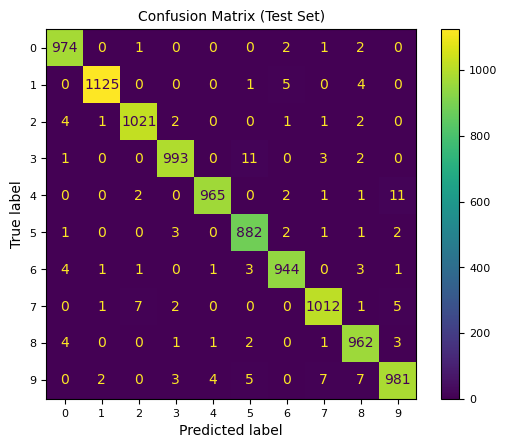

In [181]:
from sklearn.metrics import ConfusionMatrixDisplay

#model.predict returns probabilites for each class 
y_test_prob = model.predict(X_test)

#We have to convert the probabilites to predicted class labels in order to compare them with the actual labels, so 
#by using the argmax() method we take the class with the highest probability for each input 
y_test_pred = y_test_prob.argmax(axis=1)

#We will use the y_test instead of y_test_onehot for the confusion matrix as it contains the actual class labels,
#since y_test_onehot consists of one-hote encoded vectors, which can not be compared to predicted labels
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title("Confusion Matrix (Test Set)")
plt.show()